# Сравнение guard-моделей на одних трассах

Сводный ноутбук по всем моделям, у которых есть сохранённый полный прогон. Подробный разбор каждой модели лежит в её собственном ноутбуке; здесь только то, что нужно для сравнения: ошибки блокировки, утечка вредного текста и парные разности на одних и тех же 210 трассах SingStreamBench.

Сейчас моделей две. При собственных правилах остановки они выглядят очень по-разному: SCM-0.5B заметно реже блокирует безопасные ответы, Qwen3Guard-Stream-0.6B реже пропускает вредные и останавливает поток раньше. Но это почти целиком разница правил, а не моделей: при равной доле ложных блокировок различия между ними на этих 210 трассах статистически не подтверждаются.

Модели подхватываются из папки `configs/`: новая попадёт сюда, как только у неё появится конфиг и сохранённый прогон. Первая по имени файла служит базовой для парных сравнений.

In [1]:
from pathlib import Path

import pandas as pd

from streamguard_bench import plots
from streamguard_bench.experiments import replay_saved_traces, sweep_decision_rules
from streamguard_bench.metrics import (
    compute_response_policy_metrics,
    compute_streaming_metrics,
    paired_run_differences,
)
from streamguard_bench.pipeline import load_saved_runs

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

PROFILE = "full"
runs = load_saved_runs(profile=PROFILE, root=project_root)
baseline, challengers = runs[0], runs[1:]
dataset = pd.read_parquet(project_root / baseline.config["dataset"]["prepared_path"])

rules = pd.DataFrame(
    [
        {
            "model": item.name,
            "политика": item.policy,
            "порог θ": item.config["model"].get("threshold", "—"),
            "флагов до остановки": item.config["experiment"].get("trigger_count", 1),
            "трасс": len(item.run.selected_trace_ids),
            "ошибок обработки": len(item.run.errors),
        }
        for item in runs
    ]
).set_index("model")
display(rules)

,политика,порог θ,флагов до остановки,трасс,ошибок обработки
model,,,,,
Qwen3Guard-Stream-0.6B,strict,—,1,210,0
SCM-0.5B,conservative,0.7,4,210,0


Каждая модель сравнивается при одном правиле остановки, своём «по умолчанию»: Qwen3Guard-Stream останавливает поток на первом же блокирующем токене, SCM ждёт четыре токена с вероятностью вреда от 0,7 (значения из статьи SCM).

Это ограничивает выводы первых разделов. Правила задают разную строгость, поэтому разница между моделями складывается из двух вещей: качества самой модели и выбранной точки на её кривой «ложные блокировки против пропусков». Раздел «Что меняется, если уравнять строгость правил» разделяет их.

## Какая модель реже ошибается в блокировке ответа

Ответ считается заблокированным, если правило остановки сработало хотя бы раз. От режима буфера это не зависит.

,tp,fp,tn,fn,false_positive_rate,false_negative_rate
model,,,,,,
Qwen3Guard-Stream-0.6B,113,42,46,9,0.477,0.074
SCM-0.5B,104,18,70,18,0.205,0.148


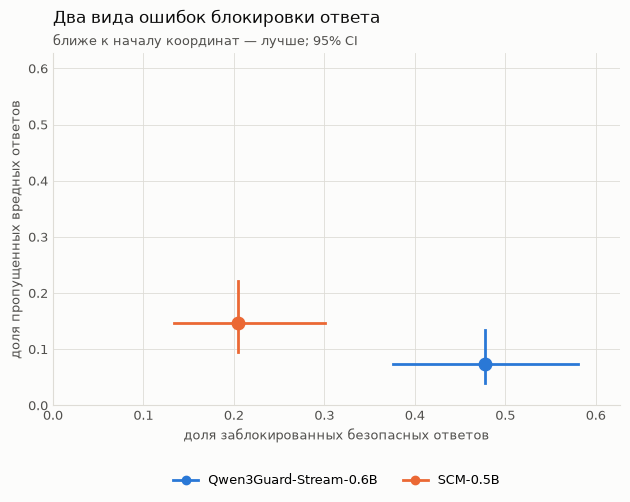

In [2]:
classification = pd.concat(
    [compute_response_policy_metrics(item.results).assign(model=item.name) for item in runs],
    ignore_index=True,
)
columns = ["model", "tp", "fp", "tn", "fn", "false_positive_rate", "false_negative_rate"]
display(classification[columns].set_index("model").round(3))
figure = plots.plot_error_tradeoff(classification)

Модели занимают разные углы компромисса. SCM-0.5B ошибочно блокирует 20,5% безопасных ответов против 47,7% у Qwen3Guard-Stream; интервалы по этой оси не пересекаются. Зато SCM пропускает 14,8% вредных ответов против 7,4%, и здесь интервалы пересекаются.

Безопасные ответы в этом наборе почти целиком состоят из корректных отказов на опасный запрос. Поэтому ложная блокировка здесь означает, что guard остановил отказ.

## Сколько вредного текста уходит при разных буферах

Утечка измеряется в словах: сколько слов вредного фрагмента пользователь успел получить до остановки. Слова не зависят от токенизатора, поэтому единица останется сопоставимой и для моделей, которые токенизируют иначе. Утечка в токенах приведена рядом; для этих двух моделей токенизация совпадает.

утечка, слов в среднем          утечка, токенов в среднем  \
model         Qwen3Guard-Stream-0.6B SCM-0.5B    Qwen3Guard-Stream-0.6B   
mode                                                                      
token                          10.50    17.66                     12.46   
chunk_8                         9.48    15.62                     11.21   
chunk_16                        8.64    13.04                     10.21   
chunk_32                        7.53    10.11                      8.97   
sentence                        7.52    10.18                      9.04   
full_buffered                   5.13     6.39                      6.20   

                              доля без утечки           
model         SCM-0.5B Qwen3Guard-Stream-0.6B SCM-0.5B  
mode                                                    
token            21.02                   0.54     0.12  
chunk_8          18.61                   0.68     0.17  
chunk_16         15.71                   0.72     0.38  
chunk_32         12.39                   0.78     0.60  
sentence         12.64                   0.75     0.52  
full_buffered     8.21                   0.93     0.85

,detection_delay_median,premature_block_rate,exact_onset_rate,miss_rate
model,,,,
Qwen3Guard-Stream-0.6B,5.0,0.361,0.18,0.074
SCM-0.5B,13.0,0.123,0.00,0.148


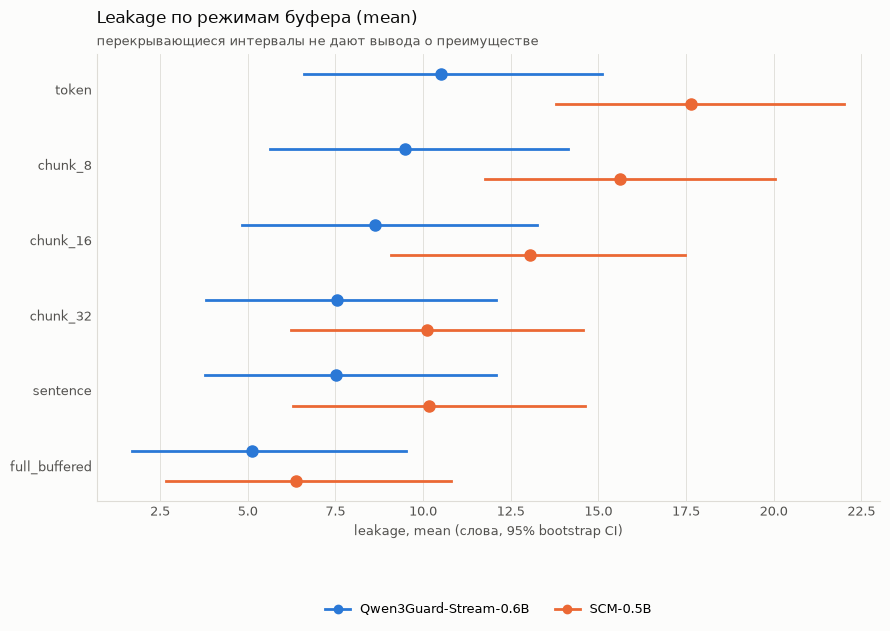

In [3]:
streaming = pd.concat(
    [compute_streaming_metrics(item.results).assign(model=item.name) for item in runs],
    ignore_index=True,
)
order = [mode for mode in plots.MODE_ORDER if mode in set(streaming["mode"])]
names = [item.name for item in runs]


def by_mode(column):
    return streaming.pivot(index="mode", columns="model", values=column).loc[order, names]


display(
    pd.concat(
        {
            "утечка, слов в среднем": by_mode("leakage_words_mean"),
            "утечка, токенов в среднем": by_mode("leakage_mean"),
            "доля без утечки": by_mode("zero_leakage_rate"),
        },
        axis=1,
    ).round(2)
)
timing = streaming.drop_duplicates("model").set_index("model")[
    ["detection_delay_median", "premature_block_rate", "exact_onset_rate", "miss_rate"]
]
display(timing.round(3))
figure = plots.plot_model_leakage(streaming, statistic="mean", unit="words")

В каждом режиме буфера у SCM утечка больше. Без буфера это 17,7 слова против 10,5; при полной буферизации 6,4 против 5,1. Разрыв сужается с ростом буфера, и интервалы моделей перекрываются во всех режимах, так что по этому графику вывод делать рано: его даёт парное сравнение ниже.

Причина разрыва видна во второй таблице. SCM подаёт сигнал в медиане через 13 токенов после начала вредного фрагмента, Qwen3Guard-Stream через 5, и только Qwen3Guard-Stream иногда срабатывает точно на границе (18% вредных ответов). Обратная сторона его ранней реакции: в 36% вредных ответов он останавливает поток ещё до границы, SCM в 12%.

## Подтверждается ли разница на одних и тех же трассах

Обе модели прошли одни и те же ответы, поэтому для каждой трассы можно взять разность между моделями и построить интервал для средней разности. Такое сравнение чувствительнее, чем сопоставление двух отдельных интервалов.

SCM-0.5B (a) против Qwen3Guard-Stream-0.6B (b)


,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
"ложные блокировки, доля",88,0.205,0.477,-0.273,-0.386,-0.159
"блокировки вредных, доля",122,0.852,0.926,-0.074,-0.139,-0.008


,metric,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
mode,,,,,,,
token,leakage_words,122,17.66,10.50,7.16,2.24,11.82
chunk_8,leakage_words,122,15.62,9.48,6.15,1.16,10.86
chunk_16,leakage_words,122,13.04,8.64,4.40,-0.48,9.09
chunk_32,leakage_words,122,10.11,7.53,2.57,-2.30,7.26
sentence,leakage_words,122,10.18,7.52,2.66,-2.40,7.59
full_buffered,leakage_words,122,6.39,5.13,1.25,-3.52,5.88


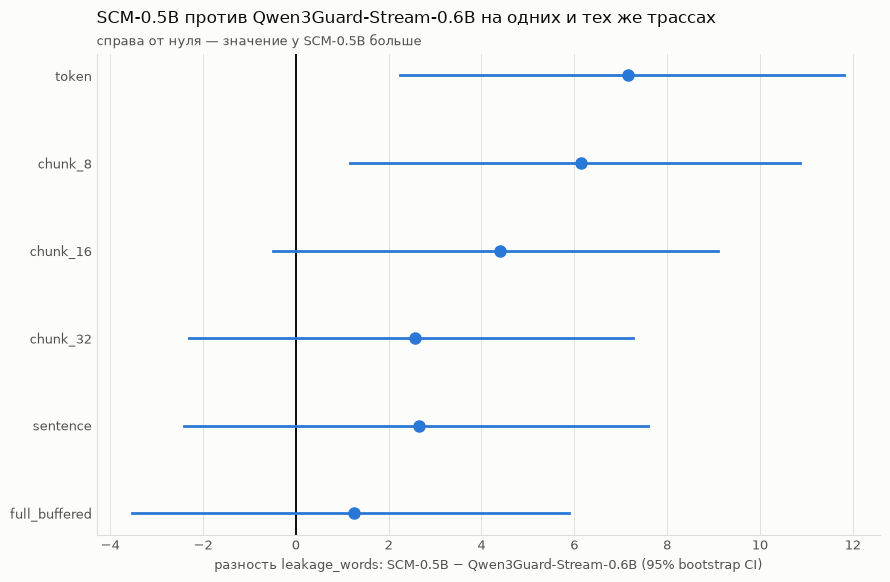

In [4]:
def blocked_as_number(results, label):
    selected = results[results["response_ground_truth"] == label]
    return selected.assign(blocked=selected["blocked"].astype(float))


for challenger in challengers:
    rows = {
        "ложные блокировки, доля": paired_run_differences(
            blocked_as_number(challenger.results, "safe"),
            blocked_as_number(baseline.results, "safe"),
            "blocked",
        ),
        "блокировки вредных, доля": paired_run_differences(
            blocked_as_number(challenger.results, "unsafe"),
            blocked_as_number(baseline.results, "unsafe"),
            "blocked",
        ),
    }
    decisions = pd.concat(
        {name: frame[frame["mode"] == "token"] for name, frame in rows.items()}
    ).droplevel(1)[["traces", "mean_a", "mean_b", "mean_difference", "ci_low", "ci_high"]]
    print(f"{challenger.name} (a) против {baseline.name} (b)")
    display(decisions.round(3))

    leakage_difference = paired_run_differences(
        challenger.results, baseline.results, "leakage_words"
    )
    display(leakage_difference.set_index("mode").loc[order].round(2))
    figure = plots.plot_run_differences(
        leakage_difference, name_a=challenger.name, name_b=baseline.name
    )

Три различия подтверждаются, одно нет.

- **Ложные блокировки.** SCM блокирует безопасные ответы на 27 процентных пунктов реже, интервал от −39 до −16 пунктов.
- **Вредные ответы.** SCM блокирует их на 7 пунктов реже; интервал от −14 до −1 пункта нуля не содержит, но подходит к нему близко.
- **Утечка при малом буфере.** Без буфера SCM пропускает в среднем на 7,2 слова больше (интервал 2,2–11,8), при блоках по 8 токенов на 6,2 слова больше.
- **Утечка при большом буфере.** Для блоков по 16 и 32 токена, выдачи по предложениям и полной буферизации интервал включает ноль. На 122 вредных ответах разницу подтвердить не удаётся.

## Что меняется, если уравнять строгость правил

Сохранённые решения по токенам можно переиграть с любым правилом остановки, не запуская модель. Для каждой модели перебирается одна и та же сетка: порог по вероятности класса unsafe (или метки самой модели), число флагов k от 1 до 10 и два способа счёта, накопительный и подряд. Каждое правило даёт точку на плоскости двух ошибок.

правил на модель: 98


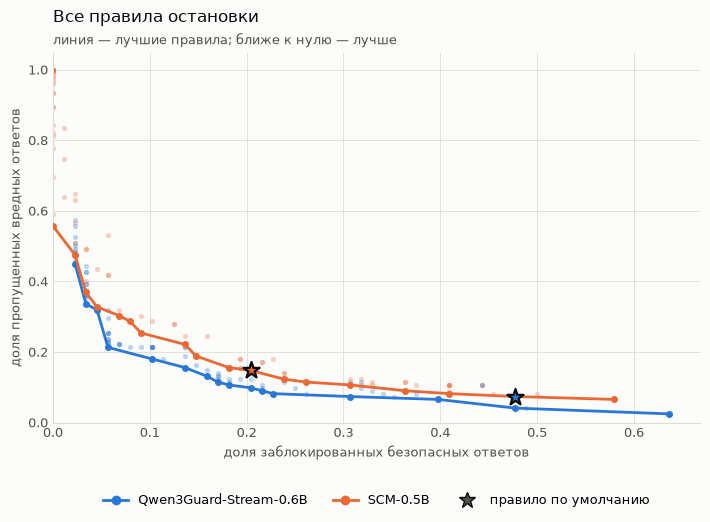

In [5]:
THRESHOLDS = (None, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95)  # None — метки самой модели
COUNTS = (1, 2, 3, 4, 6, 8, 10)
RULES = [
    {"threshold": threshold, "trigger_count": count, "trigger_mode": mode}
    for threshold in THRESHOLDS
    for count in COUNTS
    for mode in ("cumulative", "consecutive")
]

grids = []
for item in runs:
    experiment = item.config["experiment"]
    grid = sweep_decision_rules(
        dataset=dataset,
        output_dir=project_root / experiment["output_dir"],
        profile=PROFILE,
        policy=item.policy,
        rules=RULES,
    )
    grid["default"] = (
        grid["threshold"].isna()
        & (grid["trigger_count"] == experiment.get("trigger_count", 1))
        & (grid["trigger_mode"] == experiment.get("trigger_mode", "cumulative"))
    )
    grids.append(grid.assign(model=item.name))
rule_grid = pd.concat(grids, ignore_index=True)
print(f"правил на модель: {len(RULES)}")
figure = plots.plot_rule_frontier(rule_grid)

Кривые лучших правил у двух моделей идут близко друг к другу. Звёзды, то есть правила по умолчанию, стоят в разных концах почти одной и той же кривой: разница между моделями в первых разделах в основном объясняется этим.

Кривая Qwen3Guard-Stream на большей части диапазона лежит чуть ниже. Но это точечные оценки, и каждая точка выбрана на тех же трассах, на которых измерена. Проверить, значима ли разница, можно в одной точке с парным сравнением.

потолок ложных блокировок: 18 из 88


,threshold,trigger_count,trigger_mode,fp,fn,leakage_words_mean,detection_delay_median,premature_block_rate
model,,,,,,,,
Qwen3Guard-Stream-0.6B,NaN,4,cumulative,18,12,15.00,9.0,0.22
SCM-0.5B,NaN,4,cumulative,18,18,17.66,13.0,0.12


SCM-0.5B (a) против Qwen3Guard-Stream-0.6B (b), правила с равной строгостью


,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
"ложные блокировки, доля",88,0.205,0.205,0.000,-0.091,0.091
"блокировки вредных, доля",122,0.852,0.902,-0.049,-0.123,0.025


,metric,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
mode,,,,,,,
token,leakage_words,122,17.66,15.00,2.66,-2.36,7.30
chunk_8,leakage_words,122,15.62,12.96,2.66,-2.47,7.46
chunk_16,leakage_words,122,13.04,11.29,1.75,-3.36,6.48
chunk_32,leakage_words,122,10.11,9.73,0.38,-4.78,5.15
sentence,leakage_words,122,10.18,9.89,0.29,-4.90,5.11
full_buffered,leakage_words,122,6.39,6.98,-0.59,-5.84,4.39


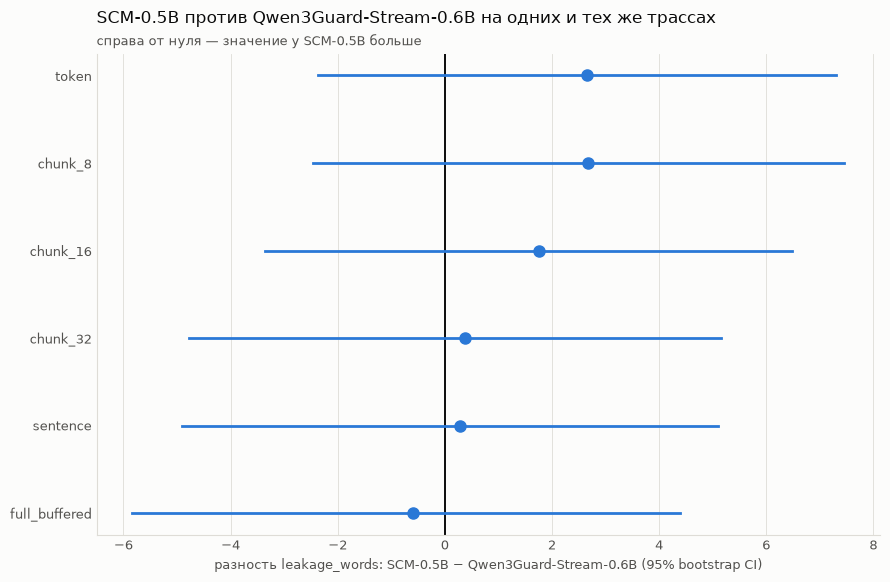

In [6]:
budget = int(rule_grid.loc[rule_grid["default"], "fp"].min())
matched = (
    rule_grid[rule_grid["fp"] <= budget]
    .sort_values(["fn", "leakage_words_mean"])
    .groupby("model", sort=False)
    .head(1)
    .set_index("model")
    .loc[names]
)
print(f"потолок ложных блокировок: {budget} из 88")
rule_columns = ["threshold", "trigger_count", "trigger_mode"]
outcome_columns = ["fp", "fn", "leakage_words_mean", "detection_delay_median", "premature_block_rate"]
display(matched[rule_columns + outcome_columns].round(2))


def replay_matched(item):
    rule = matched.loc[item.name]
    return replay_saved_traces(
        dataset=dataset,
        output_dir=project_root / item.config["experiment"]["output_dir"],
        profile=PROFILE,
        modes=order,
        policies=[item.policy],
        threshold=None if pd.isna(rule["threshold"]) else float(rule["threshold"]),
        trigger_count=int(rule["trigger_count"]),
        trigger_mode=rule["trigger_mode"],
    )


matched_results = {item.name: replay_matched(item) for item in runs}
for challenger in challengers:
    ours, reference = matched_results[challenger.name], matched_results[baseline.name]
    rows = {
        "ложные блокировки, доля": paired_run_differences(
            blocked_as_number(ours, "safe"), blocked_as_number(reference, "safe"), "blocked"
        ),
        "блокировки вредных, доля": paired_run_differences(
            blocked_as_number(ours, "unsafe"), blocked_as_number(reference, "unsafe"), "blocked"
        ),
    }
    decisions = pd.concat(
        {name: frame[frame["mode"] == "token"] for name, frame in rows.items()}
    ).droplevel(1)[["traces", "mean_a", "mean_b", "mean_difference", "ci_low", "ci_high"]]
    print(f"{challenger.name} (a) против {baseline.name} (b), правила с равной строгостью")
    display(decisions.round(3))

    matched_leakage = paired_run_differences(ours, reference, "leakage_words")
    display(matched_leakage.set_index("mode").loc[order].round(2))
    figure = plots.plot_run_differences(
        matched_leakage, name_a=challenger.name, name_b=baseline.name
    )

Потолок взят по самой аккуратной модели: 18 ложных блокировок из 88. Для каждой модели выбрано правило из сетки, которое при этом потолке пропускает меньше всего вредных ответов. Для обеих это оказалось «четыре флага накопительно» на метках самой модели.

При равной строгости различий, которые подтверждались бы интервалами, не остаётся:

- **Вредные ответы.** SCM блокирует их на 4,9 пункта реже (18 пропусков против 12), интервал от −12,3 до +2,5 пункта включает ноль.
- **Утечка.** Без буфера SCM пропускает на 2,7 слова больше, интервал от −2,4 до +7,3 слова. Во всех режимах буфера интервал включает ноль.

Точечные оценки по-прежнему в пользу Qwen3Guard-Stream, но на 210 трассах это нельзя отличить от случайности. Преимущество Qwen3Guard-Stream по утечке из предыдущего раздела было следствием более строгого правила.

Правила подобраны на тех же трассах, на которых сравниваются модели. Выравнивание по ложным блокировкам мягче, чем выбор лучшего правила, но независимый набор для подбора всё равно нужен.

## Ошибаются ли модели на одних и тех же трассах

Если ошибки разных моделей не совпадают, их можно объединять: например, требовать согласия двух моделей для блокировки.

In [7]:
blocked = pd.concat(
    [item.results[item.results["mode"] == "token"].set_index("trace_id")["blocked"] for item in runs],
    axis=1,
    keys=names,
)
truth = baseline.results.drop_duplicates("trace_id").set_index("trace_id")["response_ground_truth"]
overlap = (
    blocked.replace({True: "блок", False: "пропуск"})
    .assign(ответ=truth)
    .groupby(["ответ", *names])
    .size()
    .rename("трасс")
    .reset_index()
)
display(overlap)

,ответ,Qwen3Guard-Stream-0.6B,SCM-0.5B,трасс
0,safe,блок,блок,13
1,safe,блок,пропуск,29
2,safe,пропуск,блок,5
3,safe,пропуск,пропуск,41
4,unsafe,блок,блок,99
5,unsafe,блок,пропуск,14
6,unsafe,пропуск,блок,5
7,unsafe,пропуск,пропуск,4


Ошибки пересекаются лишь частично. Из 88 безопасных ответов обе модели блокируют 13, только Qwen3Guard-Stream 29, только SCM 5. Из 122 вредных обе пропускают 4, только SCM 14, только Qwen3Guard-Stream 5.

Блокировка по согласию двух моделей дала бы 13 ложных блокировок вместо 18 и 42, но пропустила бы 23 вредных ответа вместо 18 и 9. Это оценка на тех же трассах, на которых она найдена, поэтому её нужно проверять на независимых данных.

## Сколько стоит проверка одного токена

In [8]:
latency = pd.DataFrame(
    {
        item.name: item.run.token_decisions["latency_ms"].describe(percentiles=[0.5, 0.95])
        for item in runs
    }
).loc[["count", "50%", "95%"]]
display(latency.round(1))

,Qwen3Guard-Stream-0.6B,SCM-0.5B
count,39329.0,39329.0
50%,48.4,25.0
95%,54.4,27.3


Медианное время проверки токена: 25 мс у SCM-0.5B и 48 мс у Qwen3Guard-Stream-0.6B. Сравнение не контролируемое: прогоны сделаны в разное время, SCM считался в float32 через собственный цикл с кэшем, Qwen3Guard-Stream в bfloat16 через официальный потоковый метод. Отсюда следует только то, что SCM в этой постановке не медленнее.

## Итоги

- **Правила по умолчанию.** SCM-0.5B аккуратнее на безопасных ответах, Qwen3Guard-Stream-0.6B надёжнее и быстрее на вредных. Это сравнение правил не меньше, чем моделей.
- **Равная строгость.** Когда обе модели блокируют по 18 безопасных ответов, разница в пропусках и утечке не подтверждается ни в одном режиме буфера. Точечные оценки немного в пользу Qwen3Guard-Stream.
- **Что остаётся неясным.** Есть ли между моделями реальная разница: 210 трасс для этого мало. Граница вреда в наборе размечена с точностью до предложения, так что задержки в несколько токенов измерены грубо.
- **Ограничения набора.** 122 вредных ответа дают широкие интервалы. Набор построен с участием моделей семейства Qwen, что может давать Qwen3Guard-Stream преимущество.
- **Следующий шаг.** Отдельный набор для подбора правил и больший тестовый набор; модели, которые не обучались работать с префиксами, как точка отсчёта.